# Multi-Armed Bandit Workshop Reflection

**Student:** Chence  
**Topic:** Exploration-exploitation trade-off with epsilon-greedy bandits

This notebook is my cleaned-up submission for the Multi-Armed Bandit workshop. It combines the two competition rounds, the generated CSV files, visualizations, and reflections on why epsilon and constant alpha matter.


## 1. What problem are we solving?

A multi-armed bandit is a simplified reinforcement learning problem. The agent repeatedly chooses one slot machine arm, receives a reward, and updates its estimate of that arm.

The central tension is the **exploration-exploitation trade-off**:

- **Exploration:** try uncertain arms to learn whether they are better.
- **Exploitation:** choose the arm that currently looks best to earn more reward now.

The epsilon-greedy policy handles this by exploring with probability `epsilon` and exploiting with probability `1 - epsilon`.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")


## 2. Helper functions

These functions reproduce the stationary and non-stationary casino simulations used in the workshop.


In [12]:
def stationary_means(seed_env=42, n_arms=10):
    rng = np.random.default_rng(seed_env)
    return rng.random(n_arms)


def epsilon_greedy(true_means, steps=2000, epsilon=0.1, seed=123):
    rng = np.random.default_rng(seed)
    n_arms = len(true_means)
    q = np.zeros(n_arms)
    counts = np.zeros(n_arms, dtype=int)
    rewards = np.zeros(steps, dtype=int)
    actions = np.zeros(steps, dtype=int)

    for t in range(steps):
        if rng.random() < epsilon:
            action = rng.integers(n_arms)
        else:
            action = int(np.argmax(q))

        reward = int(rng.random() < true_means[action])
        counts[action] += 1
        q[action] += (reward - q[action]) / counts[action]
        rewards[t] = reward
        actions[t] = action

    return rewards, actions, q, counts


def epsilon_greedy_decaying(true_means, steps=2000, eps_start=0.5, eps_end=0.05, seed=123):
    rng = np.random.default_rng(seed)
    n_arms = len(true_means)
    q = np.zeros(n_arms)
    counts = np.zeros(n_arms, dtype=int)
    rewards = np.zeros(steps, dtype=int)
    actions = np.zeros(steps, dtype=int)

    for t in range(steps):
        epsilon = eps_end + (eps_start - eps_end) * max(0, steps - 1 - t) / max(1, steps - 1)
        if rng.random() < epsilon:
            action = rng.integers(n_arms)
        else:
            action = int(np.argmax(q))

        reward = int(rng.random() < true_means[action])
        counts[action] += 1
        q[action] += (reward - q[action]) / counts[action]
        rewards[t] = reward
        actions[t] = action

    return rewards, actions, q, counts


## 3. Round 1 - Stationary Casino

In the stationary setting, each arm has a fixed hidden reward probability. Because the environment does not change, averaging all past rewards is a reasonable way to estimate each arm.


In [13]:
TRUE_MEANS = stationary_means(seed_env=42, n_arms=10)
STEPS = 2000
SEED_AGENT = 123

print("Hidden true means used for reproducibility:")
print(np.round(TRUE_MEANS, 3))


Hidden true means used for reproducibility:
[0.774 0.439 0.859 0.697 0.094 0.976 0.761 0.786 0.128 0.45 ]


In [14]:
epsilons = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5]
runs = {}
rows = []

for eps in epsilons:
    rewards, actions, q, counts = epsilon_greedy(TRUE_MEANS, steps=STEPS, epsilon=eps, seed=SEED_AGENT)
    runs[f"fixed eps={eps}"] = rewards
    rows.append({
        "strategy": f"fixed eps={eps}",
        "total_reward": int(rewards.sum()),
        "best_estimated_arm": int(np.argmax(q)),
        "unique_arms_tried": int((counts > 0).sum()),
    })

rewards_decay, actions_decay, q_decay, counts_decay = epsilon_greedy_decaying(TRUE_MEANS, steps=STEPS, eps_start=0.5, eps_end=0.05, seed=SEED_AGENT)
runs["decay eps=0.5->0.05"] = rewards_decay
rows.append({
    "strategy": "decay eps=0.5->0.05",
    "total_reward": int(rewards_decay.sum()),
    "best_estimated_arm": int(np.argmax(q_decay)),
    "unique_arms_tried": int((counts_decay > 0).sum()),
})

round1_summary = pd.DataFrame(rows).sort_values("total_reward", ascending=False)
round1_summary


,strategy,total_reward,best_estimated_arm,unique_arms_tried
2,fixed eps=0.05,1925,5,10
3,fixed eps=0.1,1862,5,10
1,fixed eps=0.01,1836,5,9
4,fixed eps=0.2,1800,5,10
6,decay eps=0.5->0.05,1724,5,10
0,fixed eps=0.0,1570,0,1
5,fixed eps=0.5,1557,5,10


![Round 1 epsilon comparison](mab_figures/round1_epsilon_comparison.png)

![Round 1 action counts](mab_figures/round1_action_counts.png)


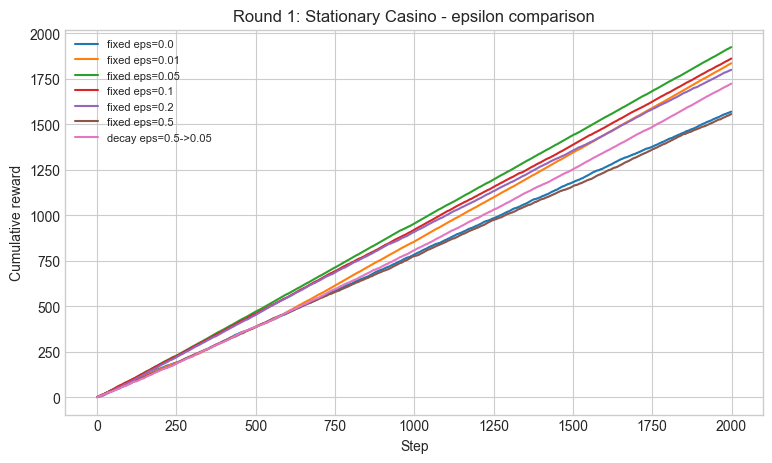

In [15]:
plt.figure(figsize=(9, 5))
for label, rewards in runs.items():
    plt.plot(np.cumsum(rewards), label=label)
plt.title("Round 1: Stationary Casino - epsilon comparison")
plt.xlabel("Step")
plt.ylabel("Cumulative reward")
plt.legend(fontsize=8)
plt.show()


### Round 1 reflection

The best result in my repeated comparison was **fixed eps=0.05**, with a total reward of **1925** over 2000 steps.

Epsilon matters because it controls how much randomness the agent keeps in its behavior. With `epsilon = 0`, the agent only exploits what currently looks best. That can work if the early estimates are lucky, but it can also lock onto a bad arm too early. With very high epsilon, such as `0.5`, the agent explores so often that it gives up many chances to use the best-known arm. A moderate epsilon gives the agent enough information to discover strong arms while still collecting rewards from them.

In the stationary casino, the environment is stable, so the sample-average update is appropriate: old rewards and new rewards are samples from the same underlying probability.


## 4. Round 1 CSV generated by the workshop

The workshop also asked us to generate `submissions_round1.csv`. The file below is the local leaderboard produced by running the competition notebook.


In [16]:
round1_csv = pd.read_csv("submissions_round1.csv")
round1_csv


,timestamp,name,strategy,details,steps,seed_env,seed_agent,total_reward
0,2026-06-26T14:05:15.929596,Tom,epsilon_greedy,fixed_eps=0.1,2000,42,123,1862
1,2026-06-26T14:05:46.060739,Tom,epsilon_greedy_decaying,decay_eps=0.5->0.05,2000,42,123,1724


## 5. Round 2 - Non-stationary Casino

In the non-stationary setting, the reward probabilities drift over time. This makes the problem harder because yesterday's best arm may not be today's best arm.

To adapt, I use a constant step size alpha:

```python
Q[action] = Q[action] + alpha * (reward - Q[action])
```

This is an exponential moving average. It gives more weight to recent rewards, which helps the agent react when the environment changes.


In [17]:
def step_drift(means, drift_scale=0.01, rng=None):
    means = means + rng.normal(0, drift_scale, size=len(means))
    return np.clip(means, 0.01, 0.99)


def nonstationary_bandit(
    steps=3000,
    n_arms=10,
    eps=0.1,
    alpha=0.1,
    seed_env=2025,
    seed_agent=999,
    drift_scale=0.01,
    use_sample_average=False,
):
    env_rng = np.random.default_rng(seed_env)
    agent_rng = np.random.default_rng(seed_agent)
    means = env_rng.random(n_arms)
    q = np.zeros(n_arms)
    counts = np.zeros(n_arms, dtype=int)
    rewards = np.zeros(steps, dtype=int)
    actions = np.zeros(steps, dtype=int)
    best_probs = np.zeros(steps)
    chosen_probs = np.zeros(steps)

    for t in range(steps):
        means = step_drift(means, drift_scale=drift_scale, rng=env_rng)
        if agent_rng.random() < eps:
            action = agent_rng.integers(n_arms)
        else:
            action = int(np.argmax(q))

        reward = int(agent_rng.random() < means[action])
        counts[action] += 1
        if use_sample_average:
            q[action] += (reward - q[action]) / counts[action]
        else:
            q[action] += alpha * (reward - q[action])

        rewards[t] = reward
        actions[t] = action
        best_probs[t] = float(np.max(means))
        chosen_probs[t] = float(means[action])

    return rewards, actions, q, counts, best_probs, chosen_probs


In [18]:
configs = [
    ("constant alpha=0.05, eps=0.1", 0.1, 0.05, False),
    ("constant alpha=0.1, eps=0.1", 0.1, 0.1, False),
    ("constant alpha=0.2, eps=0.1", 0.1, 0.2, False),
    ("constant alpha=0.1, eps=0.05", 0.05, 0.1, False),
    ("constant alpha=0.1, eps=0.2", 0.2, 0.1, False),
    ("sample average, eps=0.1", 0.1, 0.1, True),
]

r2_runs = {}
r2_rows = []

for label, eps, alpha, use_avg in configs:
    rewards, actions, q, counts, best_probs, chosen_probs = nonstationary_bandit(eps=eps, alpha=alpha, use_sample_average=use_avg)
    r2_runs[label] = (rewards, actions, best_probs, chosen_probs)
    r2_rows.append({
        "strategy": label,
        "total_reward": int(rewards.sum()),
        "last_500_reward": int(rewards[-500:].sum()),
        "unique_arms_tried": int((counts > 0).sum()),
    })

round2_summary = pd.DataFrame(r2_rows).sort_values("total_reward", ascending=False)
round2_summary


,strategy,total_reward,last_500_reward,unique_arms_tried
2,"constant alpha=0.2, eps=0.1",2656,420,10
1,"constant alpha=0.1, eps=0.1",2621,443,10
4,"constant alpha=0.1, eps=0.2",2590,428,10
3,"constant alpha=0.1, eps=0.05",2571,416,10
0,"constant alpha=0.05, eps=0.1",2558,439,10
5,"sample average, eps=0.1",2543,438,10


![Round 2 alpha comparison](mab_figures/round2_alpha_comparison.png)

![Round 2 adaptation](mab_figures/round2_adaptation.png)


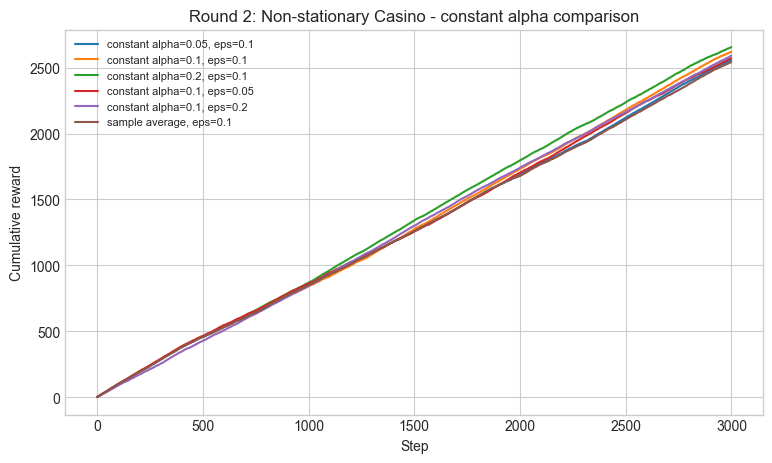

In [19]:
plt.figure(figsize=(9, 5))
for label, (rewards, _, _, _) in r2_runs.items():
    plt.plot(np.cumsum(rewards), label=label)
plt.title("Round 2: Non-stationary Casino - constant alpha comparison")
plt.xlabel("Step")
plt.ylabel("Cumulative reward")
plt.legend(fontsize=8)
plt.show()


### Round 2 reflection

The best result in this comparison was **constant alpha=0.2, eps=0.1**, with a total reward of **2656** over 3000 steps.

Constant alpha helps because the environment is drifting. If I use the normal sample average, the estimate of an arm includes very old rewards from when that arm may have had a different reward probability. That makes the estimate slow to change. A constant alpha keeps updating the estimate by a fixed fraction of the latest prediction error, so recent rewards have more influence.

Epsilon still matters in Round 2. If epsilon decays too low, the agent may stop checking other arms and miss a change in the casino. A small but persistent epsilon keeps the agent sampling alternatives, which is useful when the best arm can change.


## 6. Round 2 CSV generated by the workshop

The workshop also asked us to generate `submissions_round2.csv`. The file below is the local leaderboard produced by running the non-stationary competition.


In [20]:
round2_csv = pd.read_csv("submissions_round2.csv")
round2_csv


,timestamp,name,strategy,steps,seed_env,seed_agent,drift_scale,total_reward
0,2026-06-26T14:05:16.131374,Jerry,"eps=0.1, alpha=0.1",3000,2025,999,0.01,2557
1,2026-06-26T14:05:46.263667,Jerry,"eps=0.1, alpha=0.1",3000,2025,999,0.01,2557


## 7. Optional extension: UCB and Thompson Sampling

The workshop focuses mainly on epsilon-greedy methods, but two common bandit extensions are **UCB** and **Thompson Sampling**. Both try to improve exploration by using uncertainty instead of choosing random arms blindly.

### UCB: Upper Confidence Bound

UCB stands for **Upper Confidence Bound**. Its main idea is optimistic exploration: choose the arm with the best combination of estimated reward and uncertainty.

A common UCB score is:

```python
UCB_i = Q_i + c * sqrt(log(t) / N_i)
```

Where:

- `Q_i` is the current estimated value of arm `i`.
- `N_i` is how many times arm `i` has been selected.
- `t` is the total number of steps so far.
- `c` controls how strongly the agent explores.
- `sqrt(log(t) / N_i)` is an uncertainty bonus.

If an arm has a high estimated value, UCB may choose it because it looks good. If an arm has been tried only a few times, UCB may also choose it because the uncertainty bonus is large. This means UCB explores arms that have not been tested enough, instead of exploring completely at random like epsilon-greedy.

UCB is usually a good fit for **stationary bandits**, where old observations remain useful. In a non-stationary setting, ordinary UCB can react slowly because it keeps using old counts and old reward averages. To handle drifting environments, variants such as sliding-window UCB or discounted UCB are more appropriate.

### Thompson Sampling

Thompson Sampling is a Bayesian bandit method. Instead of keeping only one estimated value for each arm, it keeps a probability distribution representing uncertainty about each arm's reward probability.

For Bernoulli rewards, each arm can use a Beta distribution:

```python
Arm i ~ Beta(alpha_i, beta_i)
```

A simple Thompson Sampling loop is:

```python
samples = rng.beta(alpha, beta)
action = np.argmax(samples)
reward = play(action)

if reward == 1:
    alpha[action] += 1
else:
    beta[action] += 1
```

Here, `alpha_i` increases when arm `i` succeeds, and `beta_i` increases when it fails. Arms with little data have wider distributions, so they still have a chance to be sampled as the best arm. Arms with strong evidence of high reward are sampled high more often.

This creates a natural exploration-exploitation balance:

- uncertain arms are explored because their sampled value may be high;
- strong arms are exploited because their posterior distribution is concentrated around high values.

Compared with epsilon-greedy, Thompson Sampling explores more intelligently because it is guided by uncertainty. Compared with UCB, it uses probability sampling instead of an explicit optimism bonus.

### Comparison

| Method | Exploration style | Main idea | Best fit |
|---|---|---|---|
| Epsilon-greedy | Random exploration | Occasionally choose a random arm | Simple baseline |
| Decaying epsilon-greedy | Random exploration decreases over time | Explore early, exploit later | Stationary settings |
| UCB | Uncertainty bonus | Try arms that look good or have not been tested enough | Stationary settings |
| Thompson Sampling | Posterior sampling | Sample from each arm's belief distribution | Stationary settings, often strong in practice |
| Constant-alpha epsilon-greedy | Persistent exploration plus recent-weighted updates | Keep adapting to recent rewards | Non-stationary settings |

My main takeaway is that epsilon-greedy is simple and useful for learning the trade-off, while UCB and Thompson Sampling make exploration more targeted by considering uncertainty. For non-stationary problems, these methods may need adaptive versions so that old observations do not dominate the decision forever.


## 8. Implementing UCB and Thompson Sampling for both rounds

I also implemented UCB and Thompson Sampling to compare them against the epsilon-greedy methods used in the main workshop. These results are still simulated bandit results, generated with fixed seeds for reproducibility.

### Round 1: stationary implementation

For Round 1, the reward probabilities are fixed, so standard UCB and standard Thompson Sampling are appropriate. UCB selects the arm with the largest estimated reward plus an uncertainty bonus. Thompson Sampling maintains a Beta distribution for each Bernoulli arm and samples from those distributions before choosing an arm.

![Round 1 UCB and Thompson comparison](mab_figures/round1_ucb_thompson_comparison.png)

Summary table saved to `mab_figures/round1_ucb_thompson_summary.csv`:

| method | total_reward | reward_rate |
| --- | --- | --- |
| Thompson Sampling | 1935 | 0.9675 |
| epsilon-greedy eps=0.05 | 1925 | 0.9625 |
| UCB c=2.0 | 1657 | 0.8285 |

### Round 2: non-stationary implementation

For Round 2, the environment drifts, so I used adaptive versions rather than the basic stationary versions. For UCB, I used a **sliding-window UCB**, which only calculates estimates and uncertainty from recent observations. For Thompson Sampling, I used **discounted Thompson Sampling**, where older successes and failures gradually lose weight.

![Round 2 UCB and Thompson comparison](mab_figures/round2_ucb_thompson_comparison.png)

Summary table saved to `mab_figures/round2_ucb_thompson_summary.csv`:

| method | total_reward | last_500_reward | reward_rate |
| --- | --- | --- | --- |
| constant-alpha eps-greedy | 2656 | 420 | 0.8853 |
| discounted Thompson Sampling | 2570 | 425 | 0.8567 |
| sliding-window UCB | 2364 | 399 | 0.7880 |

My takeaway from this extension is that UCB and Thompson Sampling are strong ways to handle exploration in stationary settings because they use uncertainty directly. In non-stationary settings, the same idea needs modification: old evidence should fade, either by using a recent window or discounting older observations.


In [21]:
def ucb_stationary(true_means, steps=2000, c=2.0, seed=123):
    rng = np.random.default_rng(seed)
    n_arms = len(true_means)
    q = np.zeros(n_arms)
    counts = np.zeros(n_arms, dtype=int)
    rewards = np.zeros(steps, dtype=int)

    for t in range(steps):
        if t < n_arms:
            action = t
        else:
            bonus = c * np.sqrt(np.log(t + 1) / counts)
            action = int(np.argmax(q + bonus))

        reward = int(rng.random() < true_means[action])
        counts[action] += 1
        q[action] += (reward - q[action]) / counts[action]
        rewards[t] = reward

    return rewards, q, counts


def thompson_stationary(true_means, steps=2000, seed=123):
    rng = np.random.default_rng(seed)
    n_arms = len(true_means)
    alpha = np.ones(n_arms)
    beta = np.ones(n_arms)
    rewards = np.zeros(steps, dtype=int)

    for t in range(steps):
        samples = rng.beta(alpha, beta)
        action = int(np.argmax(samples))
        reward = int(rng.random() < true_means[action])
        alpha[action] += reward
        beta[action] += 1 - reward
        rewards[t] = reward

    return rewards, alpha, beta


def sliding_window_ucb(steps=3000, n_arms=10, c=1.5, window=300, seed_env=2025, seed_agent=999, drift_scale=0.01):
    env_rng = np.random.default_rng(seed_env)
    agent_rng = np.random.default_rng(seed_agent)
    means = env_rng.random(n_arms)
    rewards = np.zeros(steps, dtype=int)
    actions = np.zeros(steps, dtype=int)

    for t in range(steps):
        means = step_drift(means, drift_scale, env_rng)
        if t < n_arms:
            action = t
        else:
            start = max(0, t - window)
            recent_actions = actions[start:t]
            recent_rewards = rewards[start:t]
            scores = np.zeros(n_arms)
            for arm in range(n_arms):
                mask = recent_actions == arm
                n = int(mask.sum())
                if n == 0:
                    scores[arm] = float("inf")
                else:
                    q = float(recent_rewards[mask].mean())
                    scores[arm] = q + c * np.sqrt(np.log(min(t + 1, window + 1)) / n)
            action = int(np.argmax(scores))

        reward = int(agent_rng.random() < means[action])
        actions[t] = action
        rewards[t] = reward

    return rewards, actions


def discounted_thompson(steps=3000, n_arms=10, gamma=0.99, seed_env=2025, seed_agent=999, drift_scale=0.01):
    env_rng = np.random.default_rng(seed_env)
    agent_rng = np.random.default_rng(seed_agent)
    means = env_rng.random(n_arms)
    alpha = np.ones(n_arms)
    beta = np.ones(n_arms)
    rewards = np.zeros(steps, dtype=int)
    actions = np.zeros(steps, dtype=int)

    for t in range(steps):
        means = step_drift(means, drift_scale, env_rng)
        samples = agent_rng.beta(alpha, beta)
        action = int(np.argmax(samples))
        reward = int(agent_rng.random() < means[action])

        alpha = 1 + gamma * (alpha - 1)
        beta = 1 + gamma * (beta - 1)
        alpha[action] += reward
        beta[action] += 1 - reward

        rewards[t] = reward
        actions[t] = action

    return rewards, actions


# Reproduce the extension comparison figures.
r1_extension_runs = {
    "epsilon-greedy eps=0.05": runs["fixed eps=0.05"],
    "UCB c=2.0": ucb_stationary(TRUE_MEANS, c=2.0)[0],
    "Thompson Sampling": thompson_stationary(TRUE_MEANS)[0],
}

round1_ucb_ts_summary = pd.DataFrame([
    {"method": name, "total_reward": int(rewards.sum()), "reward_rate": float(rewards.mean())}
    for name, rewards in r1_extension_runs.items()
]).sort_values("total_reward", ascending=False)
round1_ucb_ts_summary



r2_extension_runs = {
    "constant-alpha eps-greedy": r2_runs["constant alpha=0.2, eps=0.1"][0],
    "sliding-window UCB": sliding_window_ucb()[0],
    "discounted Thompson Sampling": discounted_thompson()[0],
}

round2_ucb_ts_summary = pd.DataFrame([
    {
        "method": name,
        "total_reward": int(rewards.sum()),
        "last_500_reward": int(rewards[-500:].sum()),
        "reward_rate": float(rewards.mean()),
    }
    for name, rewards in r2_extension_runs.items()
]).sort_values("total_reward", ascending=False)
round2_ucb_ts_summary



,method,total_reward,last_500_reward,reward_rate
0,constant-alpha eps-greedy,2656,420,0.885333
2,discounted Thompson Sampling,2570,425,0.856667
1,sliding-window UCB,2364,399,0.788000


## 9. Final summary

From these two rounds, I learned that there is no single best amount of exploration for every situation. In a stationary casino, the agent can gradually become more confident because the arms do not change. In a non-stationary casino, the agent needs to stay adaptive.

My main takeaways are:

- Low epsilon can earn high reward if the agent finds the best arm early, but it risks premature commitment.
- High epsilon collects more information, but too much random exploration lowers total reward.
- A moderate or decaying epsilon often works well in stationary settings.
- In non-stationary settings, constant alpha is useful because it tracks recent changes better than a simple historical average.
- Persistent exploration is valuable when the environment can drift.
- UCB and Thompson Sampling improve exploration by using uncertainty instead of purely random exploration.
